In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from adjustText import adjust_text

In [2]:
# Global theme cho toan bo notebook
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (12, 6),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "grid.linestyle": "--",
    "grid.alpha": 0.35,
    "axes.grid": True,
})

In [3]:
pd.set_option("display.max_columns", None)

OUTPUT_DIR = Path("C:\\Users\\Lenovo\\Documents\\Neu 2025-2026\\XSTK-Material\\project\\NBA-2013-2023-injuries-analysis\\output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv("C:\\Users\\Lenovo\\Documents\\Neu 2025-2026\\XSTK-Material\\project\\NBA-2013-2023-injuries-analysis\\data\\processed\\Processed_dataset.csv")

# Standardize a few key fields for repeated use across sections
for c in ["DAYS_MISSED", "USG_PCT", "AGE", "PACE", "AVG_SPEED", "GP", "MIN", "POSS", "DRIVES", "FGA_PG"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

for c in ["INJURED_ON", "RETURNED"]:
    if c in df.columns:
        # dayfirst=True handles common sport data formats (dd/mm/yyyy)
        df[c] = pd.to_datetime(df[c], errors="coerce", dayfirst=True)

injury_date_col = "INJURED_ON"
days_col = "DAYS_MISSED"

# Defragment once to avoid pandas PerformanceWarning on later column writes
df = df.copy()

# Injury flag: either valid injury date or days missed > 0 (vectorized once)
injury_from_date = df[injury_date_col].notna() if injury_date_col in df.columns else False
injury_from_days = df[days_col].fillna(0).gt(0) if days_col in df.columns else False
df["injury_flag"] = injury_from_date | injury_from_days

print(f"Rows: {len(df):,}")
print(f"Players: {df['PLAYER_ID'].nunique():,}")
print(f"Teams: {df['TEAM'].nunique():,}")
print(f"Injury rows: {int(df['injury_flag'].sum()):,}")

Rows: 5,570
Players: 1,387
Teams: 30
Injury rows: 1,214


In [4]:
feature = pd.DataFrame(df.columns.tolist())
feature

,0
0,PLAYER_ID
1,PLAYER_NAME
2,SEASON
3,SEASON_NUM
4,AGE
...,...
111,AST_TO_PASS_PCT_ADJ
112,OREB_CHANCE_PCT
113,DREB_CHANCE_PCT
114,REB_CHANCE_PCT_ADJ


## 1) Tần suất vs mức độ nghiêm trọng
- Tần suất: số lần xuất hiện theo loại chấn thương.
- Nghiêm trọng: trung bình số ngày nghỉ (`DAYS MISSED`).

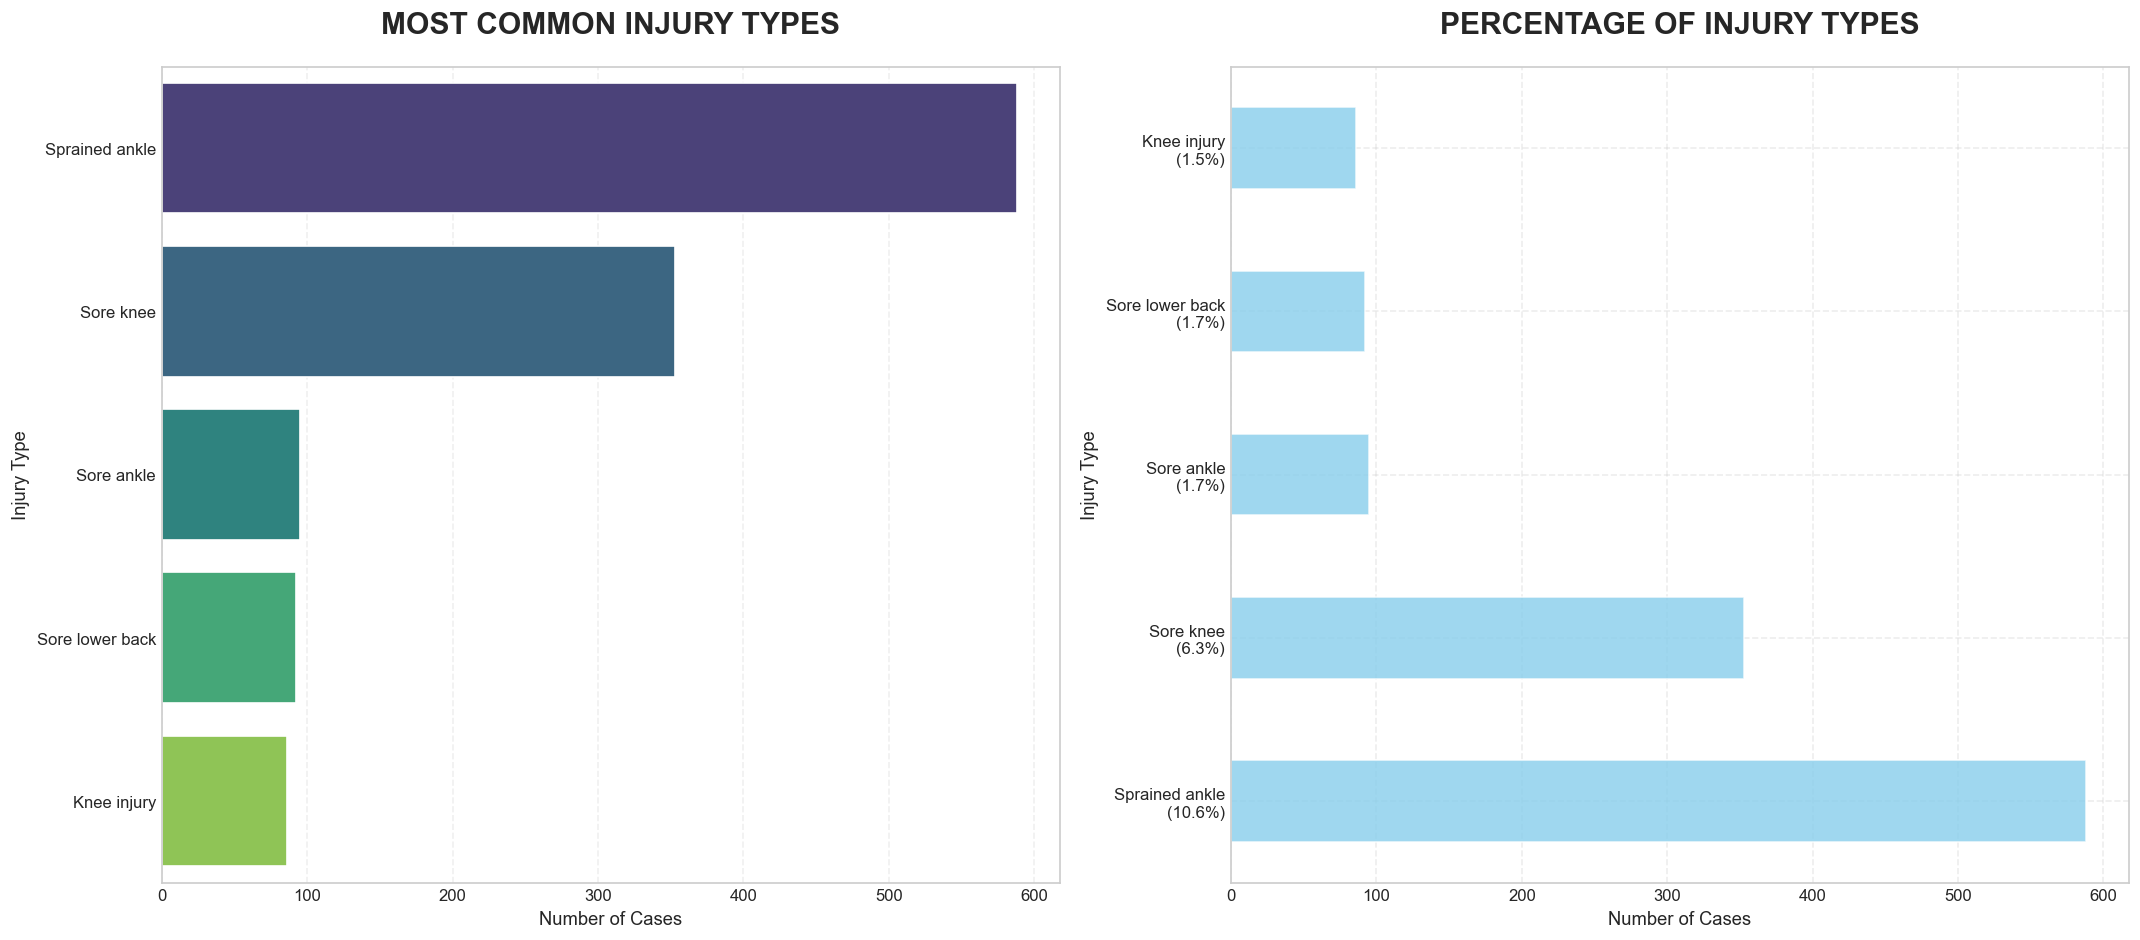

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Top 15 injury types
top_injuries = df['INJURED_TYPE'].dropna().value_counts().head(15)
top_injuries.index = [str(x).replace('_', ' ').strip() for x in top_injuries.index]
plot_left = top_injuries.rename_axis('Injury Type').reset_index(name='Count')

sns.barplot(
    data=plot_left,
    x='Count',
    y='Injury Type',
    hue='Injury Type',
    legend=False,
    ax=ax1,
    palette='viridis'
 )
ax1.set_title('MOST COMMON INJURY TYPES', fontsize=18, pad=20)
ax1.set_xlabel('Number of Cases')
ax1.set_ylabel('Injury Type')
ax1.grid(axis='x', alpha=0.3)

# Horizontal bar + percentage
total = len(df)
percent = (top_injuries / total * 100).round(1)
top_injuries.plot(kind='barh', ax=ax2, color='skyblue', alpha=0.8)
ax2.set_title('PERCENTAGE OF INJURY TYPES', fontsize=18, pad=20)
ax2.set_xlabel('Number of Cases')
ax2.set_ylabel('Injury Type')

# Add percentage to y-axis labels
ax2.set_yticks(range(len(top_injuries.index)))
ax2.set_yticklabels([f"{label}\n({pct}%)" for label, pct in zip(top_injuries.index, percent)])

plt.savefig(OUTPUT_DIR / 'top_injuries.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

,COUNT,MAX,MIN,MEDIAN,MEAN,STD
DAYS_MISSED,1214,282.0,1.0,4.0,8.752059,18.313393


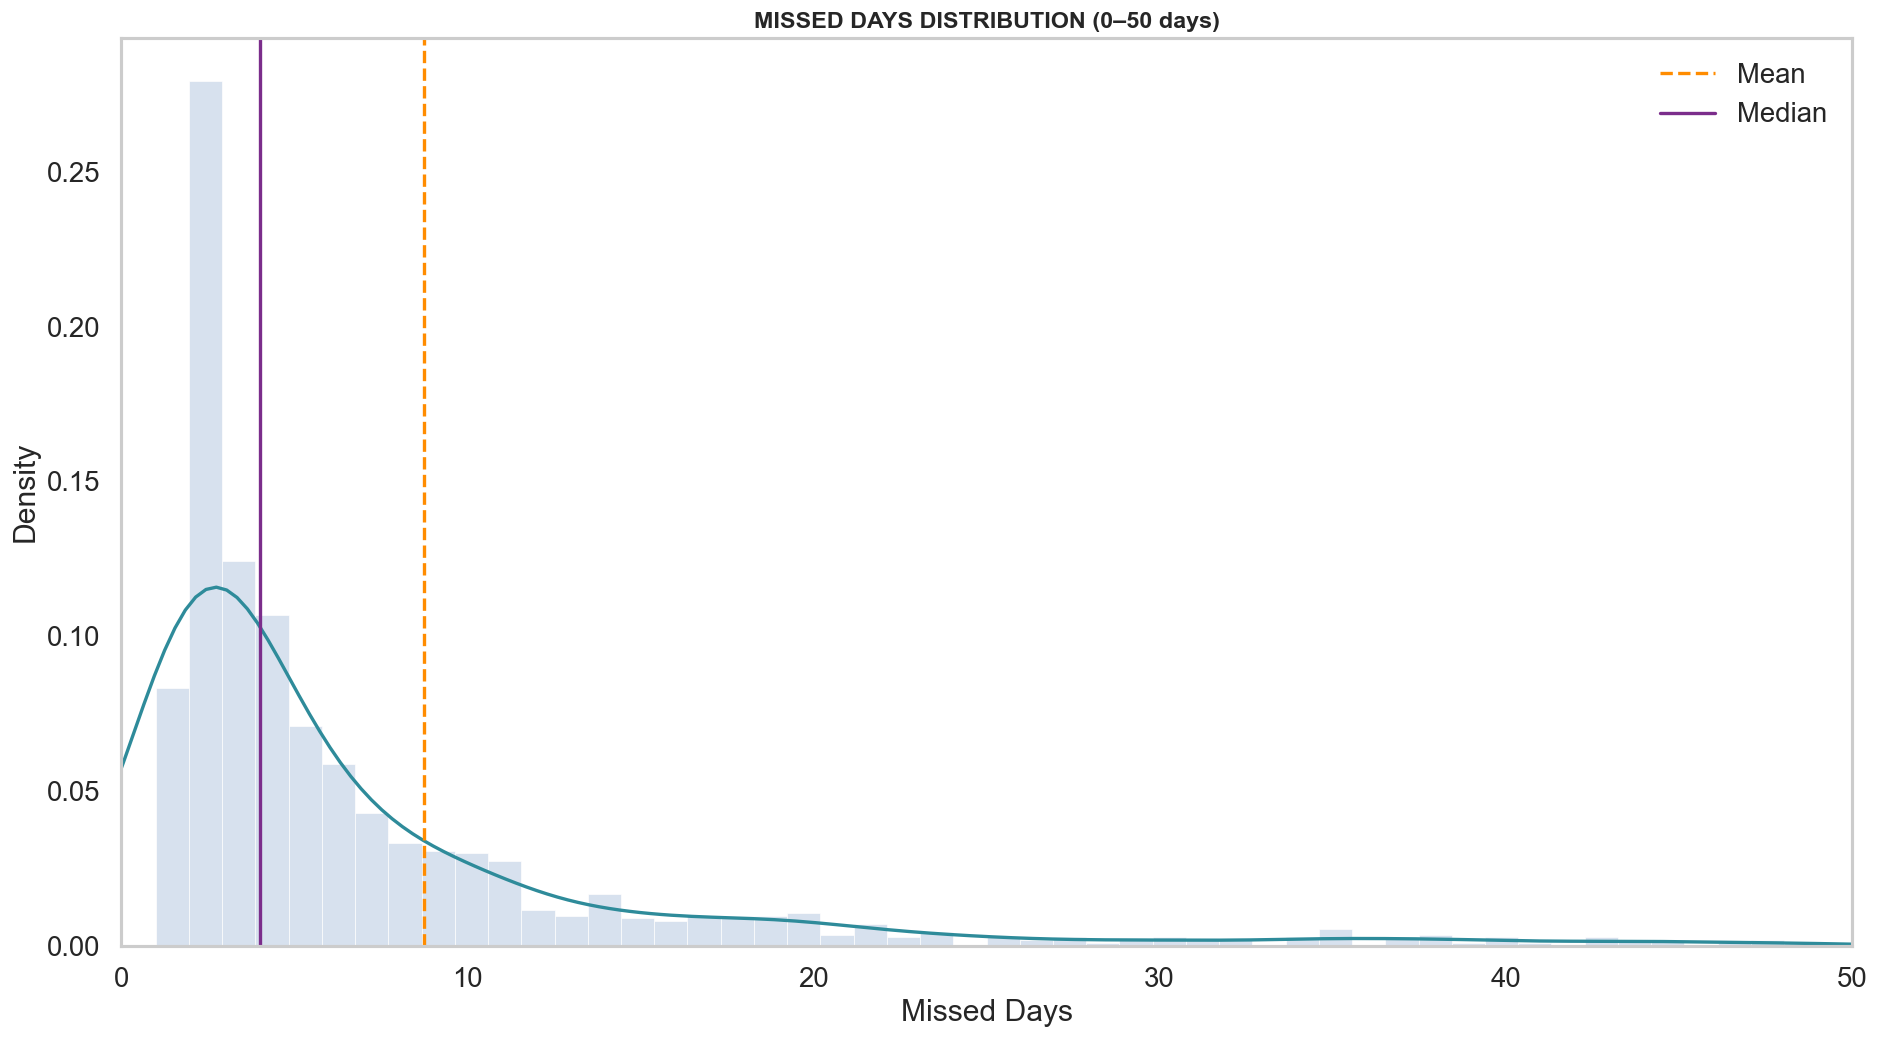

In [31]:
missed_col = "MISSED_DAYS" if "MISSED_DAYS" in df.columns else "DAYS_MISSED"

if missed_col not in df.columns:
    print(f"Thiếu cột {missed_col}")
else:
    # ===== Clean data =====
    missed_df = df[[missed_col]].copy()
    missed_df[missed_col] = pd.to_numeric(missed_df[missed_col], errors="coerce")
    missed_df = missed_df.dropna(subset=[missed_col])
    missed_df = missed_df[missed_df[missed_col] >= 0]

    if missed_df.empty:
        print("Không có dữ liệu hợp lệ để vẽ.")
    else:
        # ===== Summary stats =====
        stats_df = pd.DataFrame({
            "COUNT": [missed_df[missed_col].count()],
            "MAX": [missed_df[missed_col].max()],
            "MIN": [missed_df[missed_col].min()],
            "MEDIAN": [missed_df[missed_col].median()],
            "MEAN": [missed_df[missed_col].mean()],
            "STD": [missed_df[missed_col].std()],
        }, index=[missed_col])

        display(stats_df)

        # ===== Truncate (giữ bulk distribution) =====
        cutoff = 50
        plot_df = missed_df[missed_df[missed_col] <= cutoff]

        # ===== Plot =====
        plt.figure(figsize=(16, 9))

        # Histogram (background)
        sns.histplot(
            data=plot_df,
            x=missed_col,
            bins=50,
            stat="density",
            color="#B0C4DE",
            alpha=0.5,
            edgecolor="white",
            linewidth=0.4
        )

        # KDE (main signal)
        sns.kdeplot(
            data=plot_df,
            x=missed_col,
            color="#2E8B9A",
            linewidth=2
        )

        # Mean (full data)
        plt.axvline(
            missed_df[missed_col].mean(),
            color="#FF8C00",
            linestyle="--",
            linewidth=2,
            label="Mean"
        )

        # Median (full data)
        plt.axvline(
            missed_df[missed_col].median(),
            color="#7B2D8B",
            linestyle="-",
            linewidth=2,
            label="Median"
        )

        plt.title("MISSED DAYS DISTRIBUTION (0–50 days)", fontsize=14, fontweight="bold")
        plt.xlabel("Missed Days")
        plt.ylabel("Density")
        plt.xlim(0, cutoff)
        plt.grid( visible=False)
     
        plt.legend()
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "missed_days_distribution.png", dpi=300, bbox_inches="tight")
        plt.show()
        # ===== Save stats =====
        stats_df.to_csv(OUTPUT_DIR / "missed_days_stats.csv", index=False)

In [7]:
# Plot lớn hơn: mỗi loại chấn thương là 1 figure riêng + KDE
inj_col = "INJURED_TYPE"
missed_col = "MISSED_DAYS" if "MISSED_DAYS" in df.columns else "DAYS_MISSED"

def format_injury_name(value):
    return str(value).replace("_", " ").strip().title().upper()

if inj_col not in df.columns or missed_col not in df.columns:
    print(f"Thiếu cột bắt buộc: {inj_col} hoặc {missed_col}")
else:
    plot_df = df[[inj_col, missed_col]].copy()
    plot_df[missed_col] = pd.to_numeric(plot_df[missed_col], errors="coerce")
    plot_df = plot_df.dropna(subset=[inj_col, missed_col])
    plot_df = plot_df[plot_df[missed_col] >= 0]

    if plot_df.empty:
        print("Không có dữ liệu hợp lệ để vẽ.")
    else:
        top5_inj = plot_df[inj_col].value_counts().head(5).index.tolist()

        stats_df = (
            plot_df.groupby(inj_col)[missed_col]
            .agg(["count", "max", "min", "mean", "median", "std"])
            .rename(columns={
                "count": "COUNT",
                "max": "MAX",
                "min": "MIN",
                "mean": "MEAN",
                "median": "MEDIAN",
                "std": "STD"
            })
            .reset_index()
        )
        stats_df[inj_col] = stats_df[inj_col].map(format_injury_name)
        stats_df = stats_df.rename(columns={inj_col: "INJURED_TYPE"})

        display(stats_df)

stats_df.to_csv(OUTPUT_DIR / "injury_missed_days_stats.csv", index=False)

,INJURED_TYPE,COUNT,MAX,MIN,MEAN,MEDIAN,STD
0,KNEE INJURY,86,282.0,1.0,15.279070,2.5,40.088036
1,SORE ANKLE,95,34.0,1.0,4.873684,3.0,4.916845
2,SORE KNEE,353,212.0,1.0,6.458924,3.0,13.832773
3,SORE LOWER BACK,92,55.0,1.0,5.891304,3.5,8.093487
4,SPRAINED ANKLE,588,177.0,1.0,10.248299,5.0,17.782126


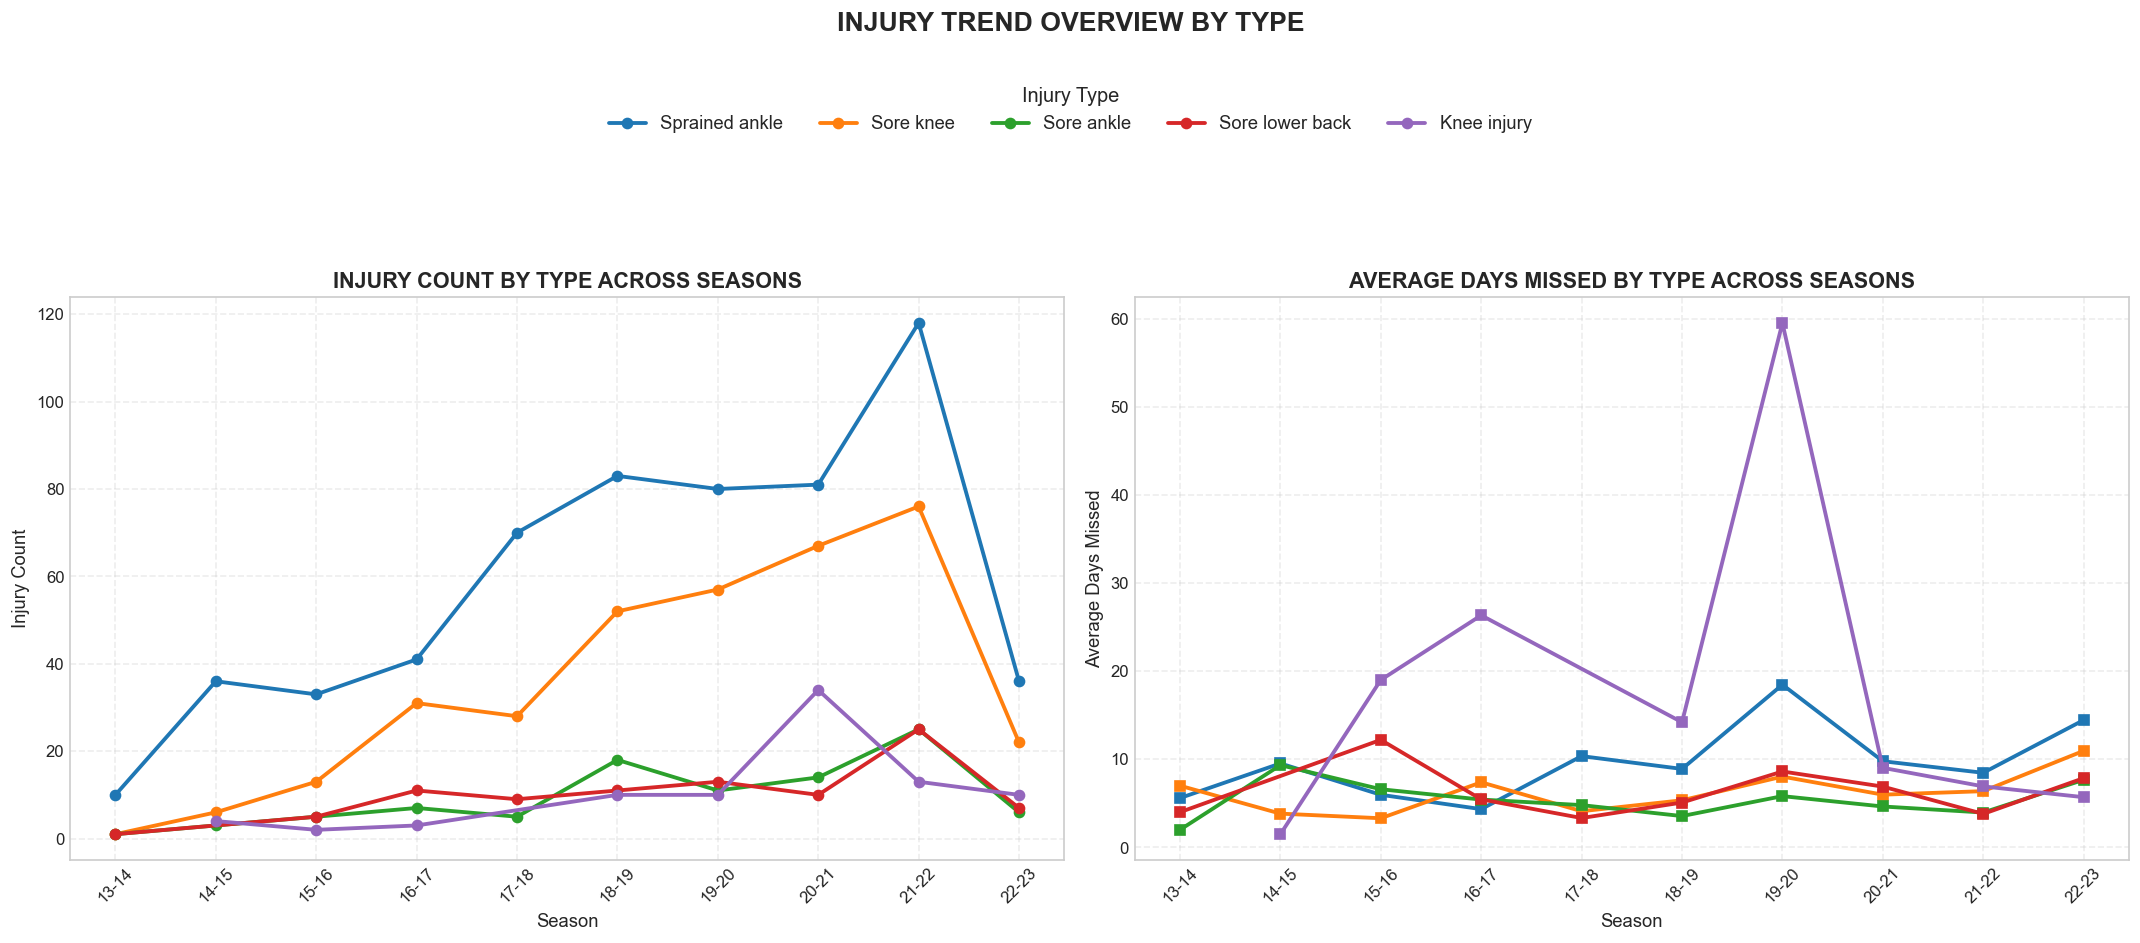

In [8]:
df_clean = df.dropna(subset=['INJURED_TYPE', 'SEASON', 'DAYS_MISSED'])

# 1) Lấy Top 5 loại chấn thương xuất hiện nhiều nhất
top_5_types = df_clean['INJURED_TYPE'].value_counts().nlargest(5).index.tolist()
df_top5 = df_clean[df_clean['INJURED_TYPE'].isin(top_5_types)].copy()

# 2) Tạo dữ liệu cho cả 2 chỉ số
seasonal_counts = (
    df_top5.groupby(['SEASON', 'INJURED_TYPE'])
    .size()
    .reset_index(name='INJURY_COUNT')
)

seasonal_avg = (
    df_top5.groupby(['SEASON', 'INJURED_TYPE'])['DAYS_MISSED']
    .mean()
    .reset_index(name='AVG_DAYS_MISSED')
)

merged = seasonal_counts.merge(
    seasonal_avg,
    on=['SEASON', 'INJURED_TYPE'],
    how='inner'
)
merged['INJURED_TYPE_LABEL'] = merged['INJURED_TYPE'].str.replace('_', ' ', regex=False).str.strip()
merged = merged.sort_values('SEASON')

# 3) 1 figure gồm 2 plot khác nhau đặt cạnh nhau
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=True)
ax1, ax2 = axes

palette = sns.color_palette('tab10', n_colors=len(top_5_types))
color_map = {t: palette[i] for i, t in enumerate(top_5_types)}

for inj_type in top_5_types:
    sub = merged[merged['INJURED_TYPE'] == inj_type]
    label = inj_type.replace('_', ' ').strip()
    color = color_map[inj_type]

    ax1.plot(
        sub['SEASON'],
        sub['INJURY_COUNT'],
        marker='o',
        linewidth=2.3,
        color=color,
        label=label
    )

    ax2.plot(
        sub['SEASON'],
        sub['AVG_DAYS_MISSED'],
        marker='s',
        linewidth=2.3,
        color=color,
        label=label
    )

ax1.set_title('INJURY COUNT BY TYPE ACROSS SEASONS', fontsize=13, fontweight='bold')
ax1.set_xlabel('Season', fontsize=11)
ax1.set_ylabel('Injury Count', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.35)
ax1.tick_params(axis='x', rotation=45)

ax2.set_title('AVERAGE DAYS MISSED BY TYPE ACROSS SEASONS', fontsize=13, fontweight='bold')
ax2.set_xlabel('Season', fontsize=11)
ax2.set_ylabel('Average Days Missed', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.35)
ax2.tick_params(axis='x', rotation=45)

# 1 legend duy nhất cho cả figure
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, title='Injury Type', loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=5)

fig.suptitle('INJURY TREND OVERVIEW BY TYPE', fontsize=16, fontweight='bold', y=1.12)
fig.tight_layout()
fig.subplots_adjust(top=0.78)

plt.savefig(OUTPUT_DIR / 'injury_trends_two_subplots_one_figure.png', dpi=300, bbox_inches='tight')
# print("Đã lưu biểu đồ vào file 'injury_trends_two_subplots_one_figure.png'")

# Xuất bảng số liệu để tham khảo
pivot_count = merged.pivot(index='SEASON', columns='INJURED_TYPE_LABEL', values='INJURY_COUNT').fillna(0)
pivot_avg = merged.pivot(index='SEASON', columns='INJURED_TYPE_LABEL', values='AVG_DAYS_MISSED').fillna(0)
# print("\nBảng số ca chấn thương:")
# print(pivot_count)
# print("\nBảng số ngày nghỉ trung bình:")
# print(pivot_avg.round(2))
plt.show()

,MEAN,MEDIAN,STD,MIN,MAX
GP,48.695691,55.000,24.375707,1.0,82.000
MIN,20.112298,19.850,9.418291,0.5,43.500
USG_PCT,0.182211,0.175,0.056184,0.0,0.571
AGE,26.533752,26.000,4.255955,19.0,43.000
PLAYER_WEIGHT,218.475763,218.000,25.275431,150.0,360.000
PLAYER_HEIGHT_INCHES,78.741831,79.000,3.430681,69.0,90.000


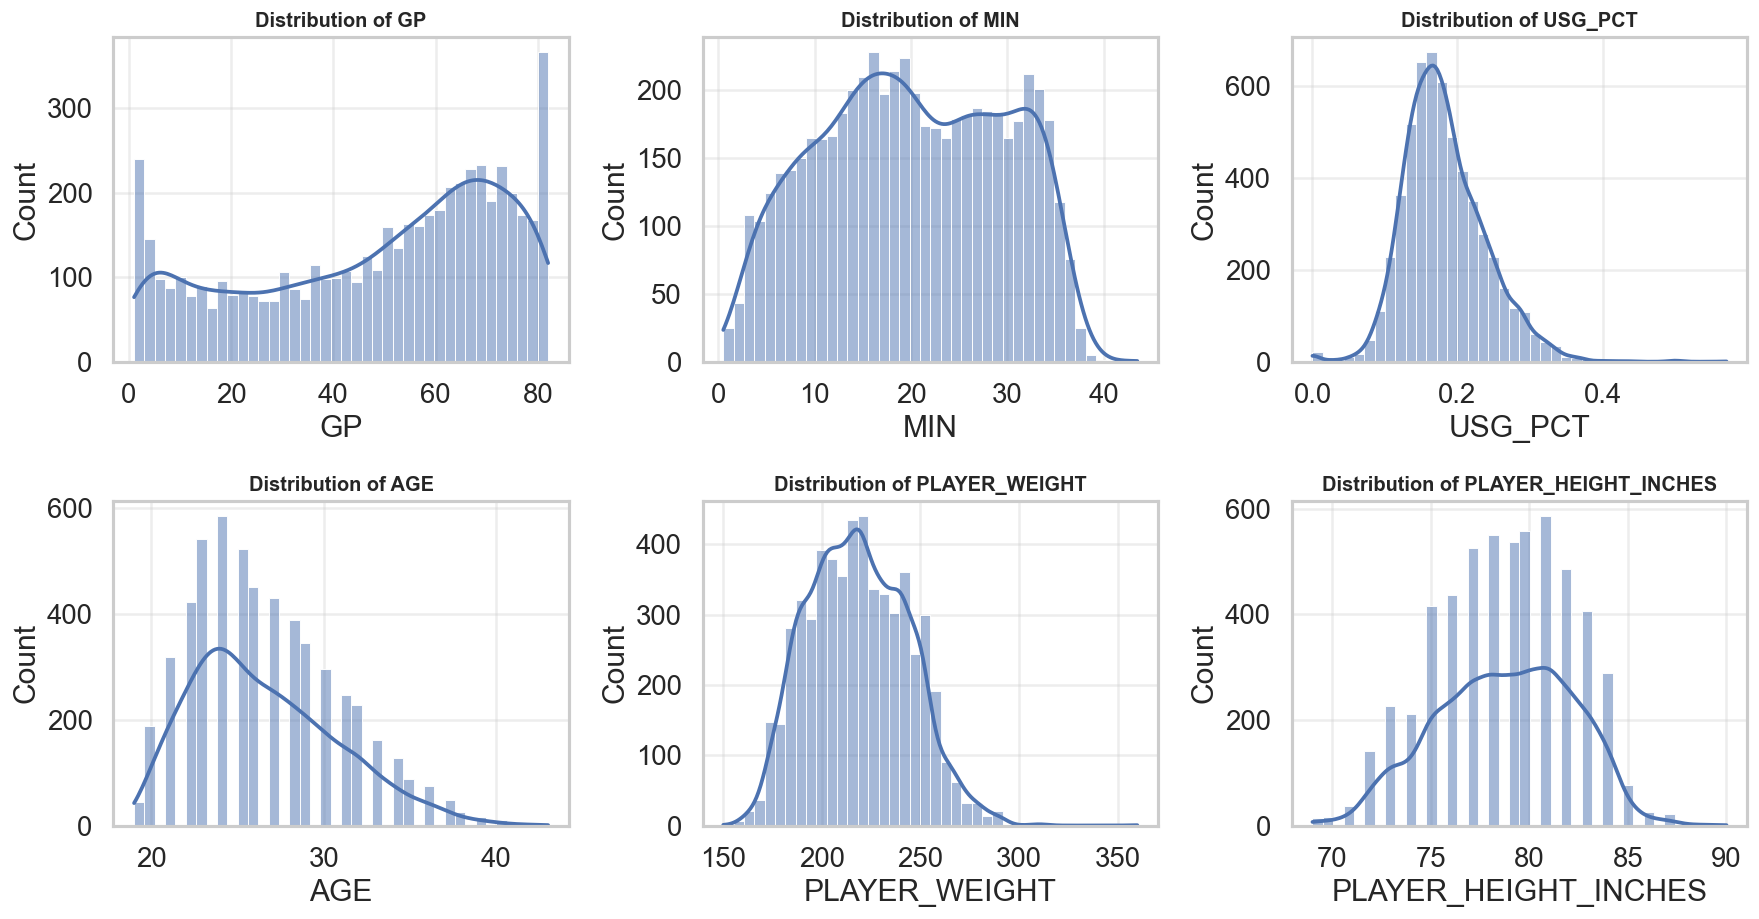

In [27]:
metrics_cols = ["GP","MIN", "USG_PCT", "AGE", "PLAYER_WEIGHT", "PLAYER_HEIGHT_INCHES"]
available_cols = [c for c in metrics_cols if c in df.columns]
missing_cols = [c for c in metrics_cols if c not in df.columns]

if missing_cols:
    print(f"Missing columns: {', '.join(missing_cols)}")

if not available_cols:
    print("No target columns available for stats/plots.")
else:
    metrics_df = df[available_cols].copy()
    for c in available_cols:
        metrics_df[c] = pd.to_numeric(metrics_df[c], errors="coerce")

    stats_table = metrics_df.agg(["mean", "median", "std", "min", "max"]).T
    stats_table = stats_table.rename(columns={
        "mean": "MEAN",
        "median": "MEDIAN",
        "std": "STD",
        "min": "MIN",
        "max": "MAX",
    })
    display(stats_table)

    n = len(available_cols)
    n_cols = 3
    n_rows = (n + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten() if n > 1 else [axes]

    for i, c in enumerate(available_cols):
        sns.histplot(metrics_df[c].dropna(), bins=40, kde=True, ax=axes[i], color="#4C72B0")
        axes[i].set_title(f"Distribution of {c}", fontsize=12, fontweight="bold")
        axes[i].set_xlabel(c)
        axes[i].set_ylabel("Count")

    for j in range(len(available_cols), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()
    stats_table.to_csv(OUTPUT_DIR / "metrics_summary_stats.csv")

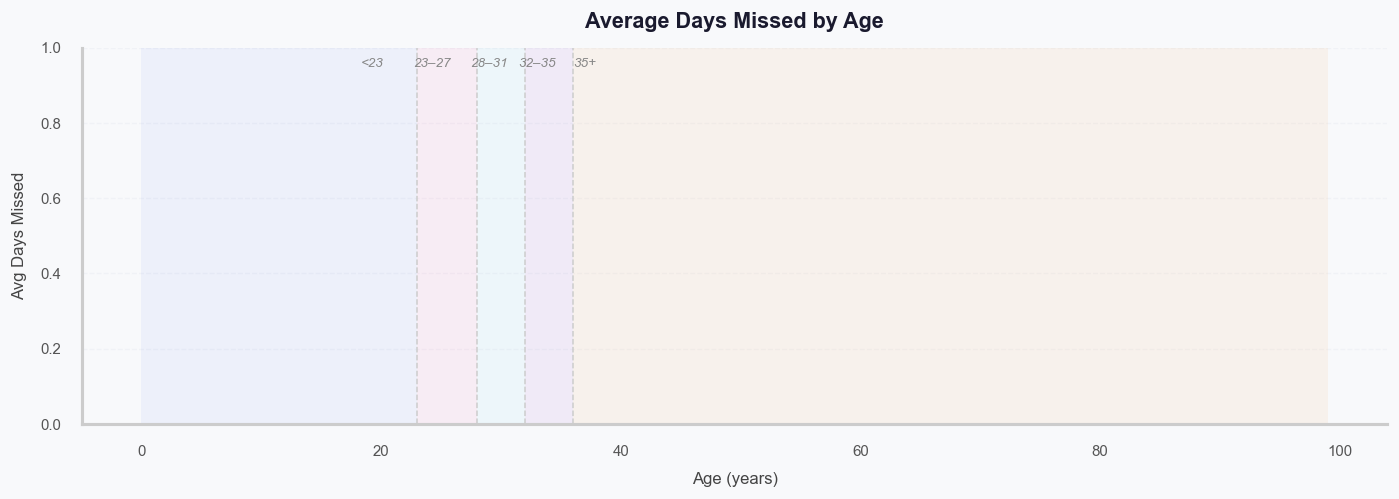

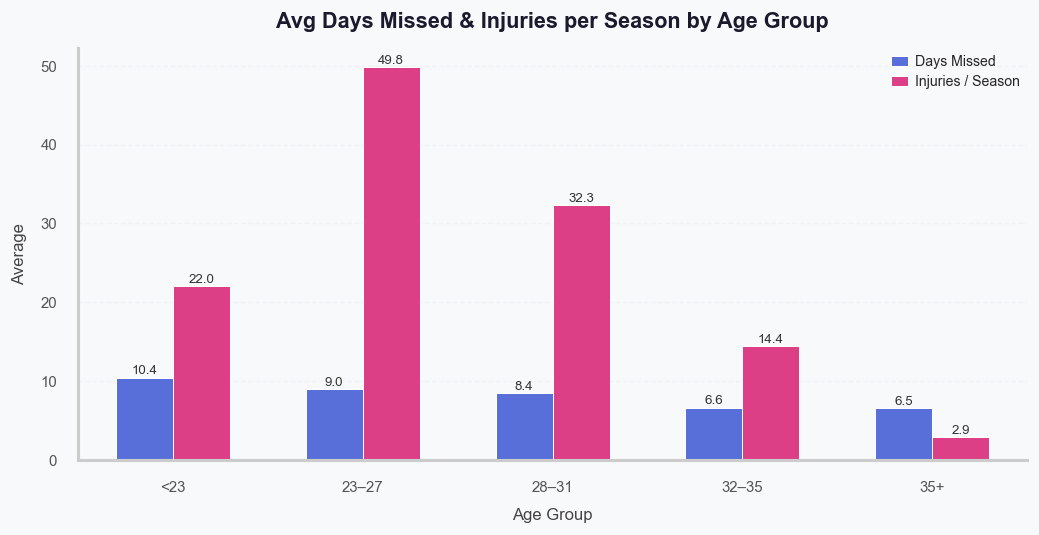

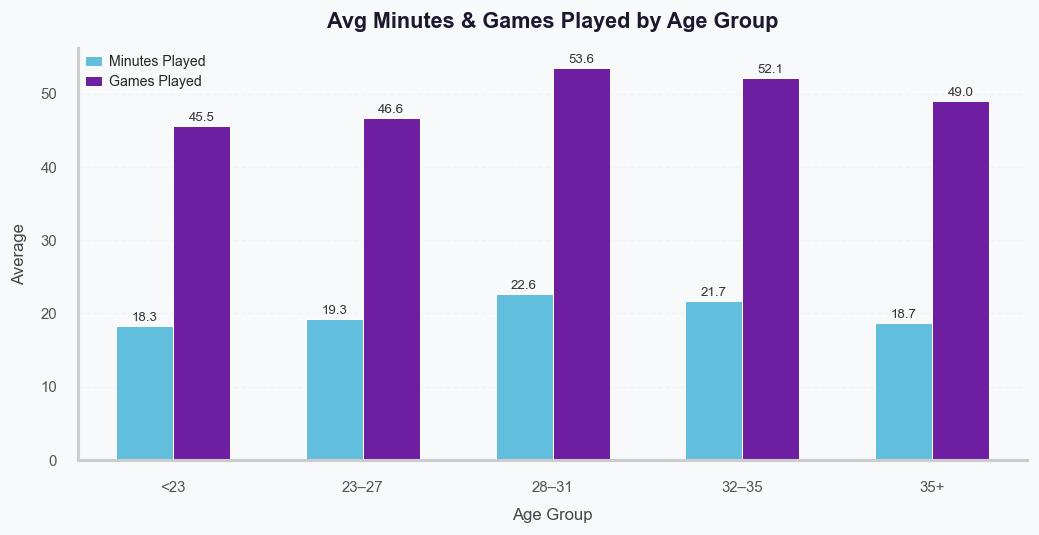

In [25]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np

# ── Shared theme ────────────────────────────────────────────────────────────
PALETTE   = ["#4361EE", "#F72585", "#4CC9F0", "#7209B7"]
BG        = "#F8F9FB"
GRID_CLR  = "#E2E5ED"
FONT_MAIN = "DejaVu Sans"

def apply_theme(ax, title, xlabel, ylabel, yformat=None):
    ax.set_facecolor(BG)
    ax.figure.set_facecolor(BG)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12, color="#1A1A2E")
    ax.set_xlabel(xlabel, fontsize=10, labelpad=8, color="#444")
    ax.set_ylabel(ylabel, fontsize=10, labelpad=8, color="#444")
    ax.tick_params(colors="#555", labelsize=9)
    ax.grid(axis="y", color=GRID_CLR, linewidth=0.8, linestyle="--")
    ax.grid(axis="x", visible=False)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#CCC")
    if yformat:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(yformat))


def compact_legend(ax):
    ax.legend(
        fontsize=8.5,
        frameon=False,
        handlelength=1.2,
        handletextpad=0.5,
        borderpad=0,
        labelspacing=0.4,
    )

# ── Age buckets (reused in all plots) ───────────────────────────────────────
bins   = [0, 23, 28, 32, 36, float("inf")]
labels = ["<23", "23–27", "28–31", "32–35", "35+"]

# ── 1. Line — Average days missed by single-year age ────────────────────────
age_col    = "AGE"
missed_col = "MISSED_DAYS" if "MISSED_DAYS" in df.columns else "DAYS_MISSED"
req = [c for c in [age_col, missed_col] if c in df.columns]
mis = [c for c in [age_col, missed_col] if c not in df.columns]

if mis:
    print(f"Missing columns: {', '.join(mis)}")
else:
    plot_df = (
        df[req].copy()
        .assign(**{age_col: lambda d: pd.to_numeric(d[age_col], errors="coerce"),
                   missed_col: lambda d: pd.to_numeric(d[missed_col], errors="coerce")})
        .dropna(subset=req)
        .query(f"{missed_col} >= 0")
    )

    if plot_df.empty:
        print("No valid data for age vs days missed plots.")
    else:
        age_avg = plot_df.groupby(age_col)[missed_col].mean().reset_index().sort_values(age_col)

        fig, ax = plt.subplots(figsize=(12, 4.5))

        # Soft age-group background shading to highlight segments
        group_spans = [(0, 23, "#4361EE"), (23, 28, "#F72585"), (28, 32, "#4CC9F0"),
                       (32, 36, "#7209B7"), (36, 99, "#F77F00")]
        for xmin, xmax, color in group_spans:
            ax.axvspan(xmin, xmax, alpha=0.06, color=color, linewidth=0)

        # Clip y-axis so negative SD doesn't stretch the chart
        ax.set_ylim(bottom=0)

        # Bold, prominent line
        ax.plot(age_avg[age_col], age_avg[missed_col],
                color="#4361EE", linewidth=2.8, zorder=4)
        ax.scatter(age_avg[age_col], age_avg[missed_col],
                   color="#4361EE", s=50, zorder=5, edgecolors="white", linewidths=1.2)

        # Annotate local peaks (top 3 ages)
        top3 = age_avg.nlargest(3, missed_col)
        for _, row in top3.iterrows():
            ax.annotate(f"{row[missed_col]:.1f}d",
                        xy=(row[age_col], row[missed_col]),
                        xytext=(0, 10), textcoords="offset points",
                        ha="center", fontsize=8.5, color="#4361EE", fontweight="bold")

        # Age group dividers
        for x in [23, 28, 32, 36]:
            ax.axvline(x, color="#CCC", linewidth=0.9, linestyle="--", zorder=1)

        # Age group labels along top
        group_centers = [(18, 20.5), (23, 25.5), (28, 30), (32, 34), (36, 38)]
        group_names   = ["<23", "23–27", "28–31", "32–35", "35+"]
        for (x0, x1), name in zip(group_centers, group_names):
            ax.text((x0 + x1) / 2, ax.get_ylim()[1] * 0.95,
                    name, ha="center", fontsize=8, color="#888", style="italic")

        apply_theme(ax,
                    title="Average Days Missed by Age",
                    xlabel="Age (years)",
                    ylabel="Avg Days Missed")
        fig.tight_layout()
        plt.show()

        # ── 2. Bar — Days missed + injuries per season by age group ─────────
        plot_df = plot_df.copy()
        plot_df["AGE_GROUP"] = pd.cut(plot_df[age_col], bins=bins, labels=labels, right=False)
        group_avg_days = plot_df.groupby("AGE_GROUP", observed=True)[missed_col].mean().reset_index()

        injury_cols = ["injury_flag", "SEASON", age_col]
        if all(c in df.columns for c in injury_cols):
            inj_df = (
                df[injury_cols].copy()
                .assign(**{age_col: lambda d: pd.to_numeric(d[age_col], errors="coerce"),
                           "injury_flag": lambda d: d["injury_flag"].astype(int)})
                .dropna(subset=[age_col, "SEASON"])
            )
            inj_df["AGE_GROUP"] = pd.cut(inj_df[age_col], bins=bins, labels=labels, right=False)
            group_avg_inj = (
                inj_df.groupby(["AGE_GROUP", "SEASON"], observed=True)["injury_flag"]
                .sum().reset_index()
                .groupby("AGE_GROUP", observed=True)["injury_flag"]
                .mean().reset_index()
                .rename(columns={"injury_flag": "AVG_INJURIES_PER_SEASON"})
            )
            group_avg = group_avg_days.merge(group_avg_inj, on="AGE_GROUP", how="left")
            avg_long  = group_avg.melt("AGE_GROUP",
                                       value_vars=[missed_col, "AVG_INJURIES_PER_SEASON"],
                                       var_name="Metric", value_name="Average")
            metric_labels = {missed_col: "Days Missed", "AVG_INJURIES_PER_SEASON": "Injuries / Season"}
            avg_long["Metric"] = avg_long["Metric"].map(metric_labels)
        else:
            avg_long = group_avg_days.rename(columns={missed_col: "Average"}).assign(Metric="Days Missed")
            avg_long["AGE_GROUP"] = avg_long["AGE_GROUP"]

        fig, ax = plt.subplots(figsize=(9, 4.8))
        bar_colors = PALETTE[:len(avg_long["Metric"].unique())]
        sns.barplot(data=avg_long, x="AGE_GROUP", y="Average", hue="Metric",
                    palette=bar_colors, ax=ax, width=0.6,
                    edgecolor="white", linewidth=0.6)

        # Value labels
        for bar in ax.patches:
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, h + 0.05,
                        f"{h:.1f}", ha="center", va="bottom", fontsize=8, color="#333")

        apply_theme(ax,
                    title="Avg Days Missed & Injuries per Season by Age Group",
                    xlabel="Age Group", ylabel="Average")

        legend = ax.get_legend()
        if legend:
            legend.remove()
        ax.legend(fontsize=8.5, frameon=False, handlelength=1.2,
                  handletextpad=0.5, borderpad=0, labelspacing=0.4)
        fig.tight_layout()
        plt.savefig(OUTPUT_DIR / "age_group_missed_injuries.png", dpi=300, bbox_inches="tight")
        plt.show()


# ── 3. Bar — Average MIN and GP by age group ────────────────────────────────
group_cols = ["MIN", "GP"]
mis_all = [c for c in [age_col] + group_cols if c not in df.columns]

if mis_all:
    print(f"Missing columns for MIN/GP plot: {', '.join(mis_all)}")
else:
    group_df = (
        df[[age_col] + group_cols].copy()
        .assign(**{age_col: lambda d: pd.to_numeric(d[age_col], errors="coerce"),
                   **{c: lambda d, col=c: pd.to_numeric(d[col], errors="coerce")
                      for c in group_cols}})
        .dropna(subset=[age_col] + group_cols)
    )

    if group_df.empty:
        print("No valid data for MIN/GP by age group plot.")
    else:
        group_df["AGE_GROUP"] = pd.cut(group_df[age_col], bins=bins, labels=labels, right=False)
        avg_long = (
            group_df.groupby("AGE_GROUP", observed=True)[group_cols]
            .mean().reset_index()
            .melt("AGE_GROUP", value_vars=group_cols, var_name="Metric", value_name="Average")
        )

        metric_labels = {"MIN": "Minutes Played", "GP": "Games Played"}
        avg_long["Metric"] = avg_long["Metric"].map(metric_labels)

        fig, ax = plt.subplots(figsize=(9, 4.8))
        sns.barplot(data=avg_long, x="AGE_GROUP", y="Average", hue="Metric",
                    palette=[PALETTE[2], PALETTE[3]], ax=ax, width=0.6,
                    edgecolor="white", linewidth=0.6)

        for bar in ax.patches:
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3,
                        f"{h:.1f}", ha="center", va="bottom", fontsize=8, color="#333")

        apply_theme(ax,
                    title="Avg Minutes & Games Played by Age Group",
                    xlabel="Age Group", ylabel="Average")

        legend = ax.get_legend()
        if legend:
            legend.remove()
        ax.legend(fontsize=8.5, frameon=False, handlelength=1.2,
                  handletextpad=0.5, borderpad=0, labelspacing=0.4)
        fig.tight_layout()
        plt.savefig(OUTPUT_DIR / "age_group_min_gp.png", dpi=300, bbox_inches="tight")
        plt.show()


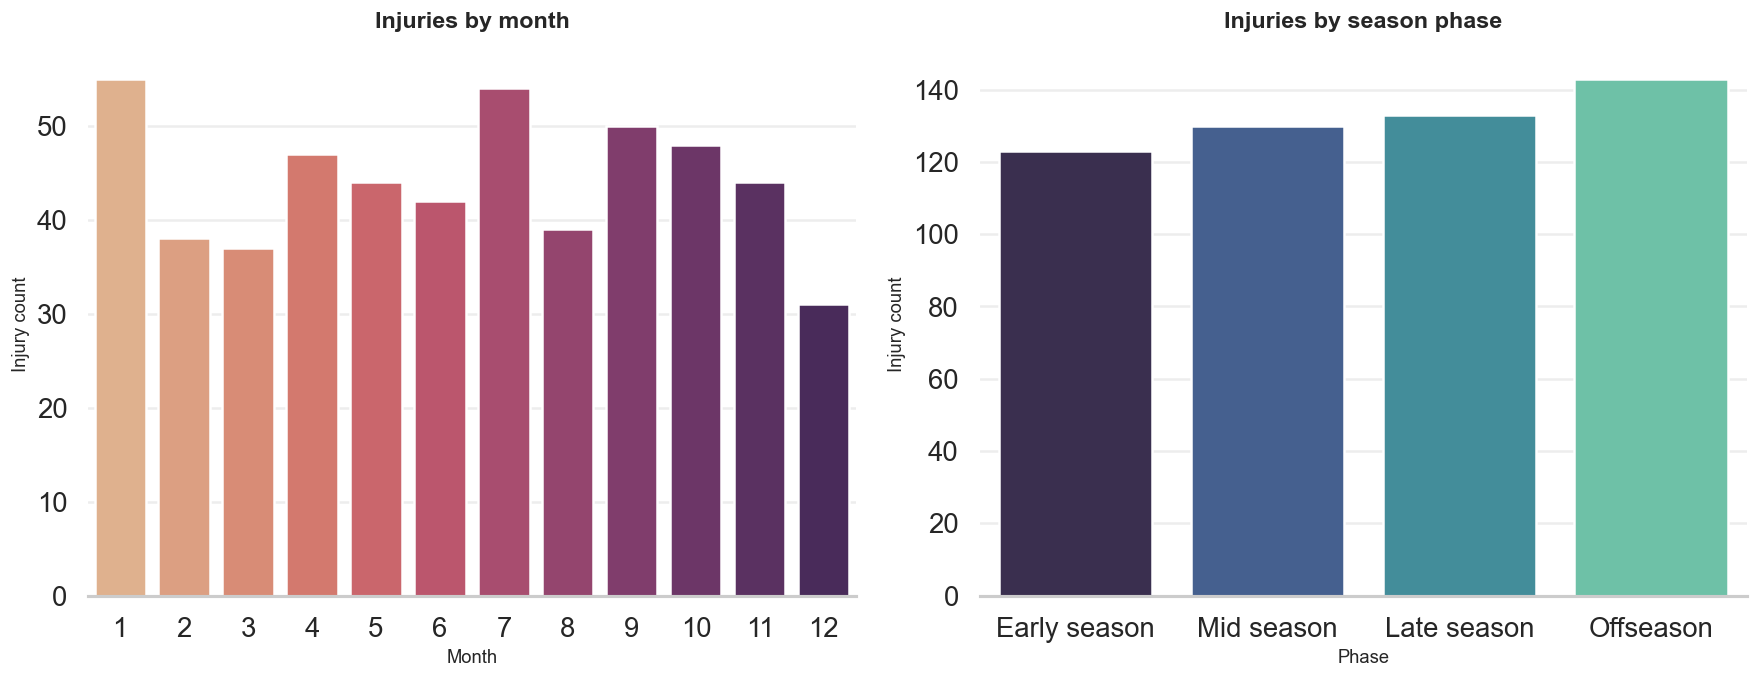

In [35]:
if injury_date_col in df.columns:
    # 1. Preprocess time data
    season_df = df[df[injury_date_col].notna()].copy()
    season_df["injury_month"] = season_df[injury_date_col].dt.month

    # 2. Map season phases to English
    # Logic: group months into ordered season phases
    phase_map = {
        10: "Early season", 11: "Early season", 12: "Early season",
        1: "Mid season", 2: "Mid season", 3: "Mid season",
        4: "Late season", 5: "Late season", 6: "Late season",
        7: "Offseason", 8: "Offseason", 9: "Offseason"
    }
    season_df["season_phase"] = season_df["injury_month"].map(phase_map).fillna("Unknown")

    # Aggregate counts
    month_counts = season_df["injury_month"].value_counts().sort_index()
    phase_counts = season_df["season_phase"].value_counts()

    # 3. Create charts
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Left chart: by month
    sns.barplot(
        x=month_counts.index,
        y=month_counts.values,
        ax=axes[0],
        palette="flare",
        hue=month_counts.index,
        legend=False
    )
    axes[0].set_title("Injuries by month", fontsize=14, weight="bold", pad=15)
    axes[0].set_xlabel("Month", fontsize=11)
    axes[0].set_ylabel("Injury count", fontsize=11)

    # Right chart: by season phase
    order = ["Early season", "Mid season", "Late season", "Offseason"]
    phase_plot = phase_counts.reindex(order).fillna(0)

    sns.barplot(
        x=phase_plot.index,
        y=phase_plot.values,
        ax=axes[1],
        palette="mako",
        hue=phase_plot.index,
        legend=False
    )
    axes[1].set_title("Injuries by season phase", fontsize=14, weight="bold", pad=15)
    axes[1].set_xlabel("Phase", fontsize=11)
    axes[1].set_ylabel("Injury count", fontsize=11)

    # Final styling
    sns.despine(left=True)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "injury_period.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print(f"Error: Injury date column '{injury_date_col}' not found in data.")

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20664\80416240.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  player_seasons = rate_df.groupby("AGE_GROUP", observed=True).apply(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20664\80416240.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("RdYlBu_r", n)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20664\80416240.py:130: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0, 1, 0.93])
C:\Users\Lenovo\Ap

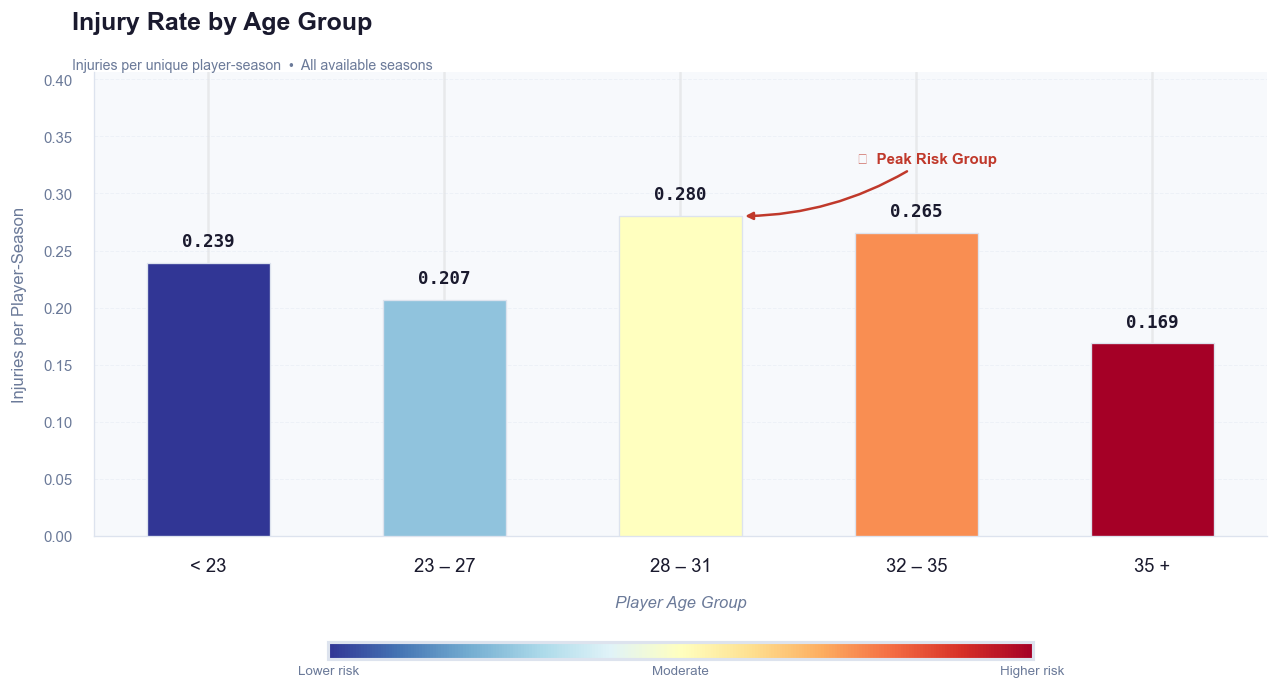

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Average days missed by age group ──────────────────────────────────────────
age_col = "AGE"
missed_col = "MISSED_DAYS" if "MISSED_DAYS" in df.columns else "DAYS_MISSED"
required = [age_col, missed_col]
missing = [c for c in required if c not in df.columns]

if missing:
    print(f"Missing columns for days missed plot: {', '.join(missing)}")
else:
    bins   = [0, 23, 28, 32, 36, float("inf")]
    labels = ["< 23", "23 - 27", "28 - 31", "32 - 35", "35 +"]

    plot_df = df[[age_col, missed_col]].copy()
    plot_df[age_col] = pd.to_numeric(plot_df[age_col], errors="coerce")
    plot_df[missed_col] = pd.to_numeric(plot_df[missed_col], errors="coerce")
    plot_df = plot_df.dropna(subset=[age_col, missed_col])
    plot_df = plot_df[plot_df[missed_col] >= 0]
    plot_df["AGE_GROUP"] = pd.cut(plot_df[age_col], bins=bins, labels=labels, right=False)

    avg_days = (
        plot_df.groupby("AGE_GROUP", observed=True)[missed_col]
        .mean()
        .reset_index(name="AVG_DAYS_MISSED")
    )

    # ── style ───────────────────────────────────────────────────────────────
    BG      = "#FFFFFF"
    PANEL   = "#F7F9FC"
    TEXT    = "#1A1A2E"
    SUBTEXT = "#6B7A99"
    BORDER  = "#DDE3EE"
    ACCENT  = "#3A86FF"

    fig, ax = plt.subplots(figsize=(10.5, 5.8), facecolor=BG)
    ax.set_facecolor(PANEL)

    x = np.arange(len(avg_days))
    values = avg_days["AVG_DAYS_MISSED"].values

    bars = ax.bar(
        x, values, width=0.55,
        color=ACCENT, edgecolor=BORDER, linewidth=0.8, zorder=3
    )

    label_offset = max(values) * 0.04 if len(values) else 0.2
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + label_offset,
            f"{val:.1f}",
            ha="center", va="bottom", fontsize=10, color=TEXT
        )

    ax.yaxis.grid(True, linestyle="--", linewidth=0.6, color=BORDER, zorder=0)
    ax.set_axisbelow(True)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(BORDER)
        ax.spines[spine].set_linewidth(0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11, color=TEXT)
    ax.tick_params(axis="y", colors=SUBTEXT, labelsize=9)
    ax.tick_params(axis="x", bottom=False)

    ax.set_xlabel("Player Age Group", fontsize=10, color=SUBTEXT, labelpad=10)
    ax.set_ylabel("Average Days Missed", fontsize=10, color=SUBTEXT, labelpad=10)
    ax.set_ylim(0, max(values) * 1.25 if len(values) else 1)

    fig.text(0.07, 0.97, "Average Days Missed by Age Group",
             fontsize=15, fontweight="bold", color=TEXT, va="top")
    fig.text(0.07, 0.905, "Mean days missed per row",
             fontsize=8.5, color=SUBTEXT, va="top")

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.savefig("avg_days_missed_by_age_group.png", dpi=180, bbox_inches="tight", facecolor=BG)
    plt.show()